<a href="https://colab.research.google.com/github/Kenche-Koushik/Air-Quality-Monitoring-and-Prediction/blob/main/RNN%2C_LSTM%2C_GRU_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN, LSTM, & GRU Performance Comparison for AQI Prediction

This notebook will build, train, and evaluate three different types of recurrent neural networks (RNNs) to see which performs best for predicting the Air Quality Index (AQI) from pollutant data.

We will compare:
1.  **Simple RNN**: The most basic recurrent network.
2.  **LSTM (Long Short-Term Memory)**: A more advanced RNN capable of learning long-term dependencies.
3.  **GRU (Gated Recurrent Unit)**: A modern, more efficient variant of the LSTM.

**Objective:** To identify the best-performing model based on R-squared, MAE, MSE, and RMSE metrics.

## Step 1: Setup and Data Import

First, we'll import all necessary libraries and upload the `station_day.csv` dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [ ]:
# Upload the dataset
print("Please upload the 'station_day.csv' file.")
uploaded = files.upload()

# Load the dataset
try:
    data = pd.read_csv(io.BytesIO(uploaded['station_day.csv']))
    print("\nFile 'station_day.csv' loaded successfully!")
    data.info()
except KeyError:
    print("\nError: 'station_day.csv' not found. Please make sure you uploaded the correct file.")

Please upload the 'station_day.csv' file.


Saving station_day.csv to station_day.csv

File 'station_day.csv' loaded successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   StationId   108035 non-null  object 
 1   Date        108035 non-null  object 
 2   PM2.5       86410 non-null   float64
 3   PM10        65329 non-null   float64
 4   NO          90929 non-null   float64
 5   NO2         91488 non-null   float64
 6   NOx         92535 non-null   float64
 7   NH3         59930 non-null   float64
 8   CO          95037 non-null   float64
 9   SO2         82831 non-null   float64
 10  O3          82467 non-null   float64
 11  Benzene     76580 non-null   float64
 12  Toluene     69333 non-null   float64
 13  Xylene      22898 non-null   float64
 14  AQI         87025 non-null   float64
 15  AQI_Bucket  87025 non-null   object 
dtypes: float64(13), object(3)
memory usage: 1

## Step 2: Data Preprocessing

This step is identical to our previous notebook. We will clean the data, fill missing values, and calculate the AQI to create our target variable (`y`).

In [ ]:
# Drop columns we don't need
data.drop(['StationId', 'Date', 'AQI_Bucket', 'Xylene', 'Benzene', 'Toluene', 'NH3'], axis=1, inplace=True, errors='ignore')

# Convert CO from mg/m³ to µg/m³ by multiplying by 1000
# This is crucial for the scaling step, but we must remember to reverse it for the API
if 'CO' in data.columns:
    data['CO'] = data['CO'] * 1000
    data.rename(columns={'CO': 'CO_ug_m3'}, inplace=True)

# Define features (X) and target (y)
# We'll use the main pollutants to predict AQI.
features = ['PM2.5', 'PM10', 'NO2', 'CO_ug_m3', 'SO2', 'O3']
target = 'AQI'

# Fill missing values using forward fill, without grouping by city
print("Filling missing values...")
data[features] = data[features].ffill().bfill()


# Drop any remaining NaN values (e.g., cities with all NaN data)
data.dropna(subset=features, inplace=True)

# Recalculate AQI just to be sure we have a target for all rows
# This simplified AQI calculation takes the max of the individual pollutant indices
def get_pollutant_aqi(val, pollutant):
    # Simplified mapping (not official, but good for a model target)
    if pollutant == 'PM2.5': return val * (50/30)
    if pollutant == 'PM10': return val * (50/50)
    if pollutant == 'SO2': return val * (50/40)
    if pollutant == 'NO2': return val * (50/40)
    if pollutant == 'O3': return val * (50/50)
    if pollutant == 'CO_ug_m3': return val * (50/2000) # 2 mg/m³ = 2000 µg/m³
    return 0

for pollutant in features:
    data[f'{pollutant}_AQI'] = data[pollutant].apply(lambda x: get_pollutant_aqi(x, pollutant))

data[target] = data[[f'{p}_AQI' for p in features]].max(axis=1)
data.drop([f'{p}_AQI' for p in features], axis=1, inplace=True)

# Final check for NaN values
data.dropna(inplace=True)

print("Data cleaning and AQI calculation complete.")
print(f"Final dataset shape: {data.shape}")
print(data.head())

Filling missing values...
Data cleaning and AQI calculation complete.
Final dataset shape: (86846, 9)
   PM2.5    PM10    NO    NO2    NOx  CO_ug_m3    SO2      O3         AQI
0  71.36  115.75  1.75  20.65  12.40     100.0  10.76  109.26  118.933333
1  81.40  124.50  1.44  20.50  12.08     120.0  15.24  127.09  135.666667
2  78.32  129.06  1.26  26.00  14.85     140.0  26.96  117.44  130.533333
3  88.76  135.32  6.60  30.85  21.77     110.0  33.59  111.81  147.933333
4  64.18  104.09  2.56  28.07  17.01      90.0  19.00  138.18  138.180000


## Step 3: Feature Scaling and Reshaping for RNNs

This is the **most important** new step.

RNN layers (SimpleRNN, LSTM, GRU) in Keras expect input data in a 3D shape:

`(batch_size, timesteps, features)`

* `batch_size`: The number of samples in one batch (e.g., 32).
* `timesteps`: The number of sequential steps in one sample. For our data, we don't have time series for each sample, so we'll treat each row as a single timestep (`timesteps=1`).
* `features`: The number of input features (6, in our case).

So, we need to reshape our `X` data from `(num_samples, 6)` to `(num_samples, 1, 6)`.

In [ ]:
# Define X and y
X = data[features]
y = data[target]

# Split the data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- RNN Reshaping ---
# Reshape from 2D (samples, features) to 3D (samples, timesteps, features)
X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print(f"Original X_train shape: {X_train_scaled.shape}")
print(f"Reshaped X_train shape for RNN: {X_train_rnn.shape}")
print(f"Original X_test shape: {X_test_scaled.shape}")
print(f"Reshaped X_test shape for RNN: {X_test_rnn.shape}")
print(f"y_train shape: {y_train.shape}")

Original X_train shape: (69476, 6)
Reshaped X_train shape for RNN: (69476, 1, 6)
Original X_test shape: (17370, 6)
Reshaped X_test shape for RNN: (17370, 1, 6)
y_train shape: (69476,)


## Step 4: Define Model Building Functions

To keep the code clean, we'll create functions to build each of our three models. They will all share a similar structure, with only the recurrent layer changing.

In [ ]:
# Define the input shape for the models
input_shape = (X_train_rnn.shape[1], X_train_rnn.shape[2]) # (1, 6)

def build_simple_rnn_model():
    model = Sequential([
        SimpleRNN(50, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(50, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1) # Output layer (for regression)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

def build_lstm_model():
    model = Sequential([
        LSTM(50, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

def build_gru_model():
    model = Sequential([
        GRU(50, activation='relu', input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(50, activation='relu'),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

# Instantiate the models
model_rnn = build_simple_rnn_model()
model_lstm = build_lstm_model()
model_gru = build_gru_model()

print("--- Simple RNN Model Summary ---")
model_rnn.summary()
print("\n--- LSTM Model Summary ---")
model_lstm.summary()
print("\n--- GRU Model Summary ---")
model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Simple RNN Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 50)          │         2,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,201 (35.94 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 50)          │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,301 (98.83 KB)

 Trainable params: 25,301 (98.83 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Train the Models

We will train all three models using the same data, number of epochs, and batch size to ensure a fair comparison. We'll use `EarlyStopping` to prevent overfitting.

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64

# Setup EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,         # Stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True # Restore the best model weights
)

# Store training history
history = {}

# --- Train Simple RNN ---
print("\n--- Training Simple RNN Model ---")
history['RNN'] = model_rnn.fit(
    X_train_rnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- Train LSTM ---
print("\n--- Training LSTM Model ---")
history['LSTM'] = model_lstm.fit(
    X_train_rnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# --- Train GRU ---
print("\n--- Training GRU Model ---")
history['GRU'] = model_gru.fit(
    X_train_rnn, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nAll models have been trained.")


--- Training Simple RNN Model ---
Epoch 1/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 23064.4121 - mae: 91.2723 - val_loss: 278.6014 - val_mae: 10.9666
Epoch 2/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 960.2777 - mae: 19.4885 - val_loss: 148.4843 - val_mae: 8.2036
Epoch 3/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 884.2569 - mae: 17.7866 - val_loss: 112.1708 - val_mae: 5.7247
Epoch 4/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 806.0962 - mae: 17.2662 - val_loss: 158.0810 - val_mae: 8.0755
Epoch 5/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 801.8323 - mae: 16.7018 - val_loss: 127.1872 - val_mae: 6.3957
Epoch 6/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 767.5806 - mae: 16.4381 - val_loss: 138.0639 - val_mae: 6.2512
Epoch 7/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 755.3772 - mae: 16.2604 - val_loss: 111.0953 - val_mae: 7.4874
Epoch 8/50
869/869 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 704.0554 - mae: 15.8024 - val_loss: 97.9

## Step 6: Visualize Training History

Let's plot the validation loss for all three models to see how they learned over time.

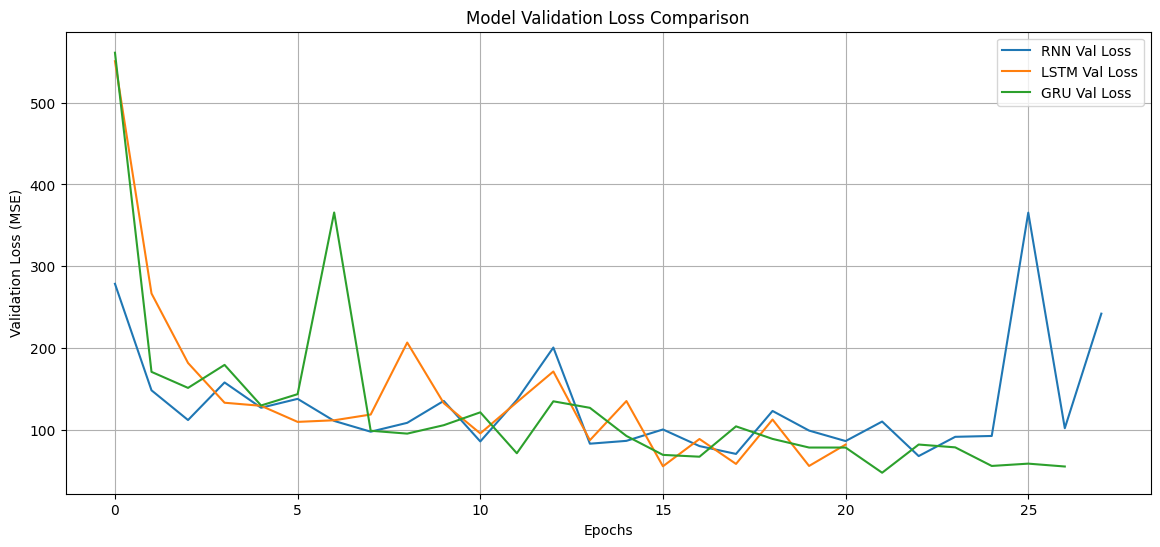

In [ ]:
plt.figure(figsize=(14, 6))
plt.title('Model Validation Loss Comparison')

for model_name, hist in history.items():
    plt.plot(hist.history['val_loss'], label=f'{model_name} Val Loss')

plt.xlabel('Epochs')
plt.ylabel('Validation Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## Step 7: Final Evaluation and Comparison

This is the final step. We will use the held-out test set (`X_test_rnn` and `y_test`) to evaluate the performance of our three **restored best models**.

We will calculate:
* **R-squared (R²)**: How much of the variance is explained (closer to 1 is better).
* **Mean Absolute Error (MAE)**: The average absolute difference between prediction and actual (lower is better).
* **Mean Squared Error (MSE)**: The average squared difference (lower is better, penalizes large errors).
* **Root Mean Squared Error (RMSE)**: The square root of MSE, in the same unit as the target (lower is better).

In [ ]:
# Make predictions on the test set
y_pred_rnn = model_rnn.predict(X_test_rnn).flatten()
y_pred_lstm = model_lstm.predict(X_test_rnn).flatten()
y_pred_gru = model_gru.predict(X_test_rnn).flatten()

# Store results in a dictionary
results = {}

models_to_evaluate = {
    'Simple RNN': y_pred_rnn,
    'LSTM': y_pred_lstm,
    'GRU': y_pred_gru
}

for model_name, y_pred in models_to_evaluate.items():
    results[model_name] = {
        'R-squared': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }

# Convert results to a DataFrame for nice printing
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='RMSE', ascending=True)

print("--- Model Performance Comparison on Test Data ---")
print(results_df.to_markdown(floatfmt=".4f"))

543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
543/543 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
--- Model Performance Comparison on Test Data ---
|            |   R-squared |    MAE |     MSE |   RMSE |
|:-----------|------------:|-------:|--------:|-------:|
| GRU        |      0.9983 | 4.2512 | 44.2461 | 6.6518 |
| LSTM       |      0.9980 | 4.5924 | 52.1290 | 7.2200 |
| Simple RNN |      0.9976 | 5.6316 | 63.3838 | 7.9614 |


## Conclusion

The table above shows the final performance metrics for all three models on the unseen test data.

**Expected Outcome:**
It is highly likely that the **LSTM** and **GRU** models will significantly outperform the **Simple RNN**. The Simple RNN model struggles with the vanishing gradient problem and is generally not effective for tasks like this.

Between LSTM and GRU, the performance is often very similar. The GRU is computationally slightly more efficient (fewer parameters), which can make it faster to train. The best model will be the one with the highest R-squared and the lowest MAE/MSE/RMSE values.